In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)

block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
words_shuffled = words.copy()
random.shuffle(words_shuffled)

n1 = int(0.8 * len(words_shuffled))
n2 = int(0.9 * len(words_shuffled))

Xtr, Ytr = build_dataset(words_shuffled[:n1])
Xdev, Ydev = build_dataset(words_shuffled[n1:n2])
Xte, Yte = build_dataset(words_shuffled[n2:])

print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


In [2]:
n_embd = 10       # embedding size (instead of previous 2, a little bigger)
n_hidden = 200    # hidden layer size (instead of previous 100, a little bigger)

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

11897


In [3]:
ix = torch.randint(0, Xtr.shape[0], (32,))
Xb, Yb = Xtr[ix], Ytr[ix]

emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print(loss.item())

25.854021072387695


In [4]:
print(logits[0])

tensor([ 12.4119,  -7.6996,   2.3776,   6.5568,  -6.7900, -15.6000, -21.2102,
         -0.6893,  13.2828, -12.5420,  -4.2807,  25.9170,   1.7245, -19.7246,
          2.6588,   7.7760, -15.6614,  14.8147,  16.6351,  -9.3979,  -6.0412,
         -2.7174,  -1.9348,  -4.2945,  -9.4654,  -5.1644,   0.7409],
       grad_fn=<SelectBackward0>)


In [5]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [6]:
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print(loss.item())

3.309950590133667


In [7]:
print(hpreact.abs())
print((hpreact.abs() > 0.99).float().mean())

tensor([[ 9.8810,  1.9506,  0.1427,  ...,  0.1273,  5.3983,  7.5101],
        [ 8.5732,  0.6641, 14.2602,  ...,  3.0853,  4.3294,  1.5491],
        [ 9.2223,  2.5425, 17.2360,  ...,  4.6610,  2.0363,  2.9357],
        ...,
        [ 5.0469,  4.0583,  2.7587,  ..., 10.2891, 10.6158,  5.9261],
        [10.8226,  1.7919, 11.2321,  ...,  0.2998,  6.2545,  1.3529],
        [ 2.1496,  4.6512,  8.5526,  ...,  3.7208,  0.8364,  1.7751]],
       grad_fn=<AbsBackward0>)
tensor(0.8552)


In [8]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [9]:
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print('loss:', loss.item())

print('saturation ratio:', (hpreact.abs() > 0.99).float().mean().item())

loss: 3.298351764678955
saturation ratio: 0.3579687476158142


In [10]:
fan_in = n_embd * block_size   # 30
W1_scale = 1 / (fan_in ** 0.5)
print(W1_scale)

0.18257418583505536


In [11]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)

fan_in = n_embd * block_size
W1_scale = (fan_in ** -0.5)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * W1_scale
b1 = torch.randn(n_hidden, generator=g) * 0.01

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [12]:
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print('loss:', loss.item())
print('saturation ratio:', (hpreact.abs() > 0.99).float().mean().item())

loss: 3.2976150512695312
saturation ratio: 0.31296876072883606


In [13]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)

W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

12297


iter 0: loss=3.3147
iter 3000: loss=2.2337
iter 6000: loss=2.1222
iter 9000: loss=2.2276
iter 12000: loss=2.2050
iter 15000: loss=2.0817
iter 18000: loss=2.0346
iter 21000: loss=2.4454
iter 24000: loss=2.4277
iter 27000: loss=2.3306
weight   (27, 10) | mean +0.000000 | std 1.372768e-02 | grad:data ratio 1.354209e-02
weight  (30, 200) | mean -0.000032 | std 1.156665e-02 | grad:data ratio 3.523635e-02
weight  (200, 27) | mean -0.000000 | std 1.925358e-02 | grad:data ratio 1.354028e-01
weight   (1, 200) | mean -0.001237 | std 9.934551e-03 | grad:data ratio 6.121303e-02
weight   (1, 200) | mean -0.000362 | std 2.405395e-02 | grad:data ratio 1.097813e-01


/var/folders/rh/q8pfrjx50mn9l741h3kc17w40000gn/T/ipykernel_98983/3545057129.py:44: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (


Text(0.5, 1.0, 'gradient distribution (weights)')

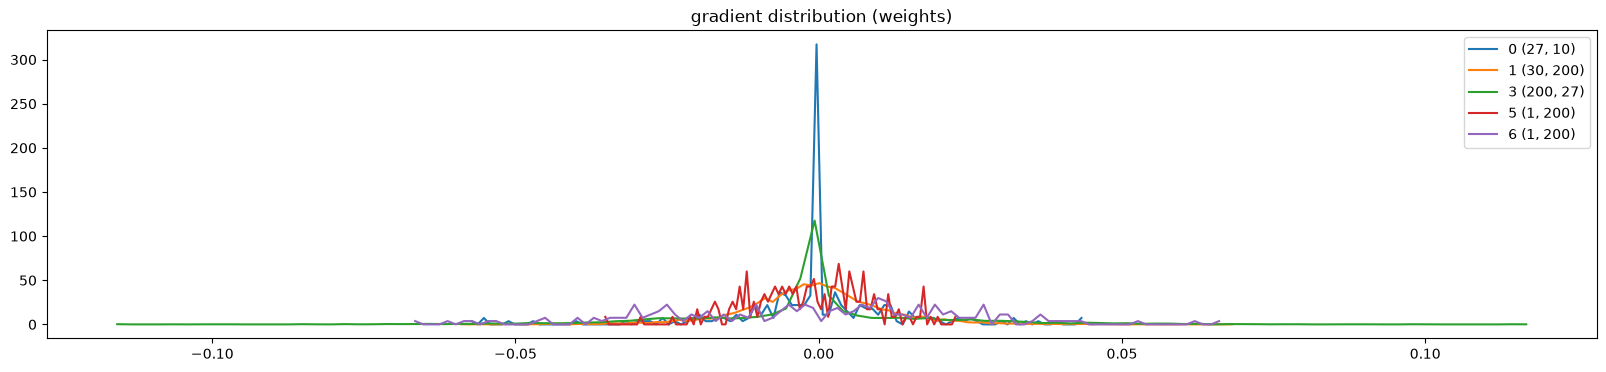

In [14]:
max_steps = 30000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    # batch normalization
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias

    h = torch.tanh(hpreact)
    h.retain_grad()
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 15000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 3000 == 0:
        print(f'iter {i}: loss={loss.item():.4f}')
    lossi.append(loss.log10().item())



plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:   # lets look just 2-dimensional (matrix) parameters (as W1, W2)
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (
            tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('gradient distribution (weights)')

In [15]:
@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'dev': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    # batch norm - by using statistics of all training-set
    hpreact = bngain * (hpreact - hpreact_mean) / hpreact_std + bnbias

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

# firstly let's calculate the statistics for the entire training-set
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact_mean = hpreact.mean(0, keepdim=True)
    hpreact_std = hpreact.std(0, keepdim=True)

split_loss('train')
split_loss('dev')

train 2.158886671066284
dev 2.172434091567993


Text(0.5, 1.0, 'h (activation) distribution')

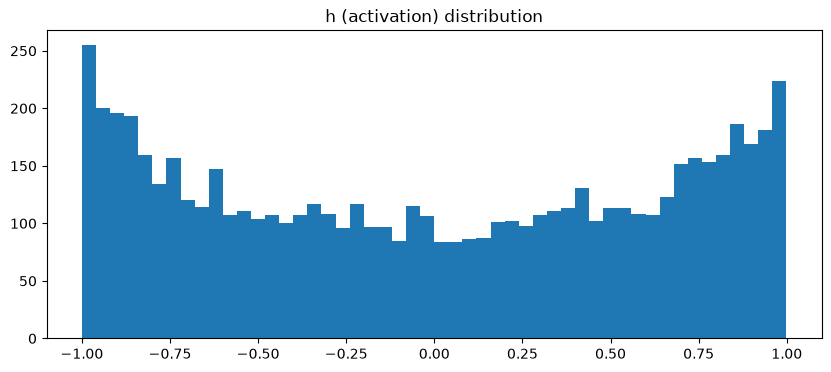

In [16]:
plt.figure(figsize=(10,4))
plt.hist(h.view(-1).tolist(), 50)
plt.title('h (activation) distribution')

Text(0.5, 1.0, 'h gradient distribution')

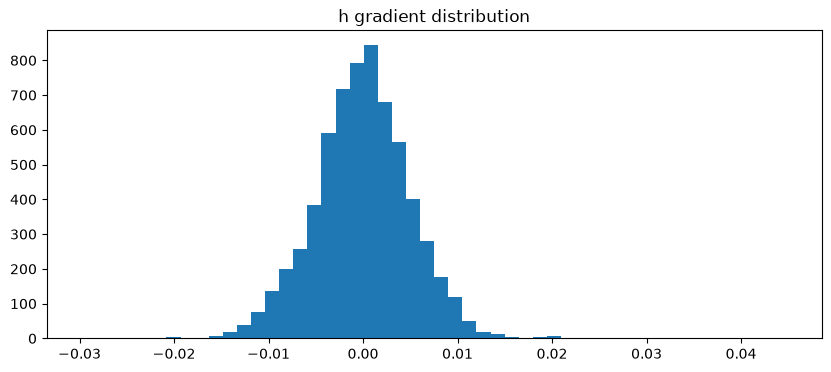

In [17]:
plt.figure(figsize=(10, 4))
plt.hist(h.grad.view(-1).tolist(), 50)
plt.title('h gradient distribution')

In [18]:
max_steps = 30000
batch_size = 32
lossi = []
ud = []   # the list where we accumulate the data rates

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 15000 else 0.01
    with torch.no_grad():
        for p in parameters:
            p.data += -lr * p.grad

    # save data ratio
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i % 3000 == 0:
        print(f'iter {i}: loss={loss.item():.4f}')
    lossi.append(loss.log10().item())

iter 0: loss=2.3697
iter 3000: loss=2.3022
iter 6000: loss=2.1770
iter 9000: loss=2.1299
iter 12000: loss=2.3477
iter 15000: loss=1.9150
iter 18000: loss=2.4432
iter 21000: loss=2.7531
iter 24000: loss=2.1932
iter 27000: loss=1.6606


Text(0.5, 1.0, 'update:data ratio (over time, log10)')

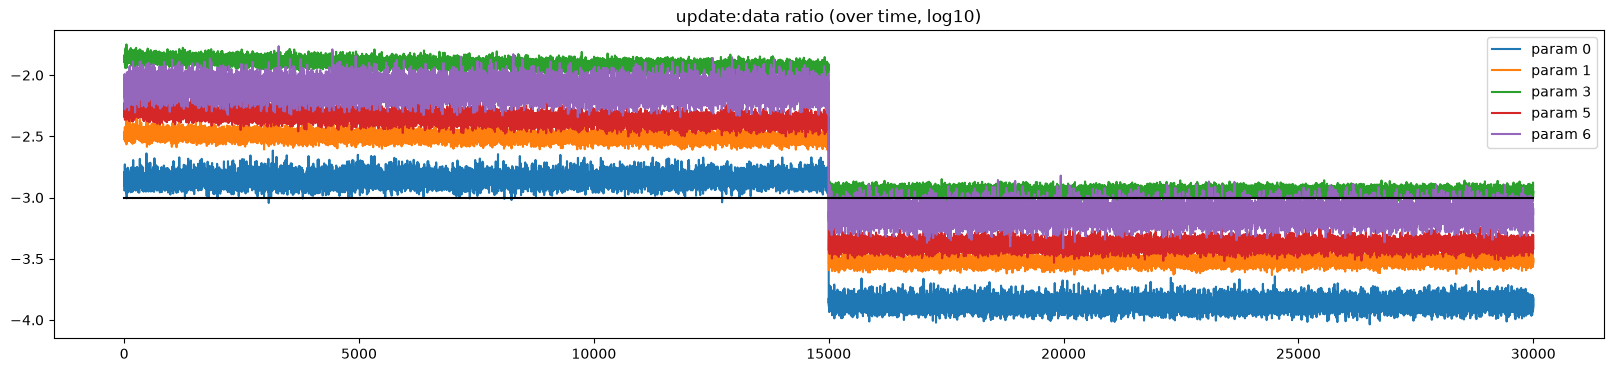

In [19]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k')   # reference line: -3 (namely 1/1000 ratio)
plt.legend(legends)
plt.title('update:data ratio (over time, log10)')

In [21]:
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    torch.nn.Linear(n_embd * block_size, n_hidden, bias=False),
    torch.nn.BatchNorm1d(n_hidden),
    torch.nn.Tanh(),
    torch.nn.Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1   # the last layer starts small, just like the previous one

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [22]:
ix = torch.randint(0, Xtr.shape[0], (32,))
Xb, Yb = Xtr[ix], Ytr[ix]

emb = C[Xb]
x = emb.view(emb.shape[0], -1)
for layer in layers:
    x = layer(x)
loss = F.cross_entropy(x, Yb)
print(loss.item())


3.2871549129486084


In [23]:
max_steps = 30000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 15000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 3000 == 0:
        print(f'iter {i}: loss={loss.item():.4f}')
    lossi.append(loss.log10().item())

iter 0: loss=3.2662
iter 3000: loss=2.3127
iter 6000: loss=2.3605
iter 9000: loss=1.9431
iter 12000: loss=2.2051
iter 15000: loss=2.3002
iter 18000: loss=2.1091
iter 21000: loss=2.2035
iter 24000: loss=1.8916
iter 27000: loss=1.9867


In [24]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    torch.nn.Linear(n_embd * block_size, n_hidden, bias=False),
    torch.nn.BatchNorm1d(n_hidden),
    # torch.nn.Tanh(),   ← It is removed this!
    torch.nn.Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

12097


In [25]:
max_steps = 30000
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 15000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 3000 == 0:
        print(f'iter {i}: loss={loss.item():.4f}')

iter 0: loss=3.3063
iter 3000: loss=2.4571
iter 6000: loss=2.4713
iter 9000: loss=2.1106
iter 12000: loss=2.2180
iter 15000: loss=2.4140
iter 18000: loss=2.3013
iter 21000: loss=2.2559
iter 24000: loss=2.1293
iter 27000: loss=2.2914
